# Amazon Yorumları Duygu Analizi

### Dosya Okuma

In [9]:
!pip install openpyxl


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd

In [11]:
df = pd.read_excel('amazon.xlsx')
df.head()

,Star,HelpFul,Title,Review
0,5,0,looks great,Happy with it
1,5,0,Pattern did not align between the two panels.,Good quality material however the panels are m...
2,5,0,Imagery is stretched. Still fun.,Product was fun for bedroom windows.<br />Imag...
3,5,0,Que se ven elegantes muy finas,Lo unico que me gustaria es que sean un poco ...
4,5,0,Wow great purchase,Great bang for the buck I can't believe the qu...


### Veri Ön İşleme

In [ ]:
# Tüm harfleri küçük harfe çevirme (normalizing case folding)
df["Review"] = df["Review"].str.lower()

In [13]:
df.head()

,Star,HelpFul,Title,Review
0,5,0,looks great,happy with it
1,5,0,Pattern did not align between the two panels.,good quality material however the panels are m...
2,5,0,Imagery is stretched. Still fun.,product was fun for bedroom windows.<br />imag...
3,5,0,Que se ven elegantes muy finas,lo unico que me gustaria es que sean un poco ...
4,5,0,Wow great purchase,great bang for the buck i can't believe the qu...


In [14]:
# Noktalama işaretlerini kaldırma (punctuations)
df["Review"] = df["Review"].str.replace('[^\w\s]','', regex=True)

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
C:\Users\İlayda\AppData\Local\Temp\ipykernel_9268\4243949488.py:2: SyntaxWarning: invalid escape sequence '\w'
  df["Review"] = df["Review"].str.replace('[^\w\s]','', regex=True)


In [15]:
df.head()

,Star,HelpFul,Title,Review
0,5,0,looks great,happy with it
1,5,0,Pattern did not align between the two panels.,good quality material however the panels are m...
2,5,0,Imagery is stretched. Still fun.,product was fun for bedroom windowsbr imagery ...
3,5,0,Que se ven elegantes muy finas,lo unico que me gustaria es que sean un poco ...
4,5,0,Wow great purchase,great bang for the buck i cant believe the qua...


In [16]:
# Yorumlarda bulunan sayısal ifadeleri çıkarma
df["Review"] = df["Review"].str.replace('\d', '', regex=True)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\İlayda\AppData\Local\Temp\ipykernel_9268\799525651.py:2: SyntaxWarning: invalid escape sequence '\d'
  df["Review"] = df["Review"].str.replace('\d', '', regex=True)


In [18]:
df.head()

,Star,HelpFul,Title,Review
0,5,0,looks great,happy with it
1,5,0,Pattern did not align between the two panels.,good quality material however the panels are m...
2,5,0,Imagery is stretched. Still fun.,product was fun for bedroom windowsbr imagery ...
3,5,0,Que se ven elegantes muy finas,lo unico que me gustaria es que sean un poco ...
4,5,0,Wow great purchase,great bang for the buck i cant believe the qua...


In [20]:
# Bilgi içermeyen kelimeleri (stopwords) kaldırma
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
sw = stopwords.words('english')
df['Review'] = df['Review'].apply(lambda x: ' '.join([word for word in str(x).split() if word not in (sw)]))
df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\İlayda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Star,HelpFul,Title,Review
0,5,0,looks great,happy
1,5,0,Pattern did not align between the two panels.,good quality material however panels mismatched
2,5,0,Imagery is stretched. Still fun.,product fun bedroom windowsbr imagery bit stre...
3,5,0,Que se ven elegantes muy finas,lo unico que gustaria es que sean un poco mas ...
4,5,0,Wow great purchase,great bang buck cant believe quality material ...


In [ ]:
# 1 den az geçen kelimeleri veriden çıkarma (rarewords)

temp_df = pd.Series(' '.join(df['Review']).split()).value_counts()
temp_df

curtains      1891
love          1312
room          1116
like          1037
beautiful      943
              ... 
gamers           1
crispbr          1
wfh              1
relatively       1
elephant         1
Name: count, Length: 6699, dtype: int64

In [24]:
drops = temp_df[temp_df <= 1]
drops

estas          1
mismatched     1
funbr          1
accompanied    1
knowing        1
              ..
gamers         1
crispbr        1
wfh            1
relatively     1
elephant       1
Name: count, Length: 3695, dtype: int64

In [25]:
df['Review'] = df['Review'].apply(lambda x: ' '.join([word for word in str(x).split() if word not in (drops)]))
df.head()

,Star,HelpFul,Title,Review
0,5,0,looks great,happy
1,5,0,Pattern did not align between the two panels.,good quality material however panels
2,5,0,Imagery is stretched. Still fun.,product fun bedroom windowsbr imagery bit stre...
3,5,0,Que se ven elegantes muy finas,lo que es que un poco mas
4,5,0,Wow great purchase,great bang buck cant believe quality material ...


In [ ]:
# Lemmatization (Kök bulma)
from textblob import Word

# nltk.download('wordnet', download_dir="nltk_data")

[nltk_data] Downloading package wordnet to nltk_data...


True

In [28]:
df['Review'] = df['Review'].apply(lambda x: ' '.join([Word(word).lemmatize() for word in str(x).split()]))
df.head()

,Star,HelpFul,Title,Review
0,5,0,looks great,happy
1,5,0,Pattern did not align between the two panels.,good quality material however panel
2,5,0,Imagery is stretched. Still fun.,product fun bedroom windowsbr imagery bit stre...
3,5,0,Que se ven elegantes muy finas,lo que e que un poco ma
4,5,0,Wow great purchase,great bang buck cant believe quality material ...


### Metin Görselleştirme

In [29]:
# Barplot görselleştirme

tf = df['Review'].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis = 0).reset_index()
tf.columns = ['words', 'tf']

C:\Users\İlayda\AppData\Local\Temp\ipykernel_9268\2276041442.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tf = df['Review'].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis = 0).reset_index()
C:\Users\İlayda\AppData\Local\Temp\ipykernel_9268\2276041442.py:3: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  tf = df['Review'].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis = 0).reset_index()
C:\Users\İlayda\AppData\Local\Temp\ipykernel_9268\2276041442.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tf = df['Review'].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis = 0).reset_index()
C:\Users\İlayda\AppData\Local\Temp\ipykernel_9268\2276041442.py:3: FutureWarning: value_count

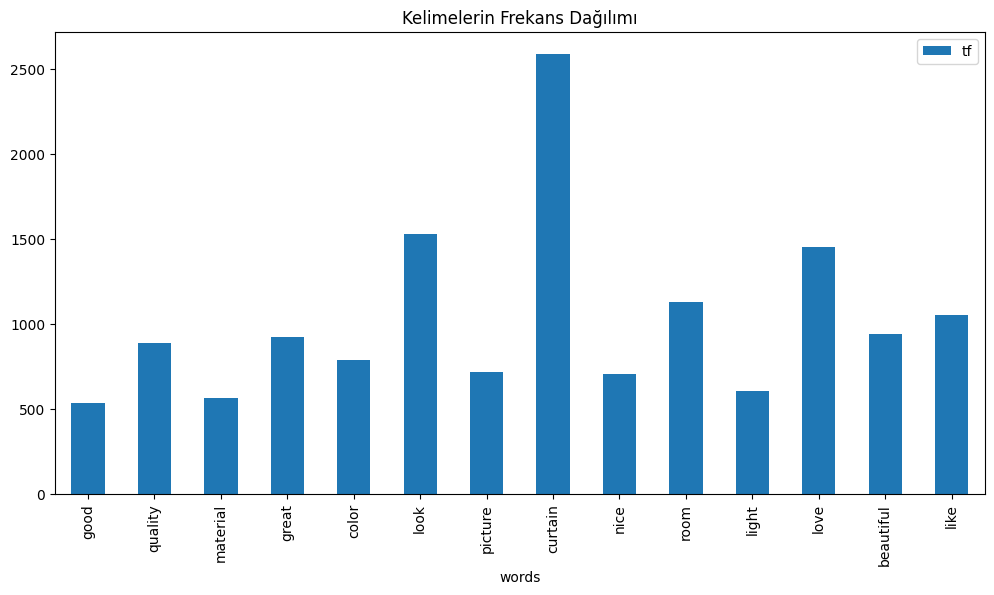

In [31]:
import matplotlib.pyplot as plt

tf[tf['tf'] >= 500].plot.bar(x='words', y='tf', figsize=(12,6), title='Kelimelerin Frekans Dağılımı')
plt.show()

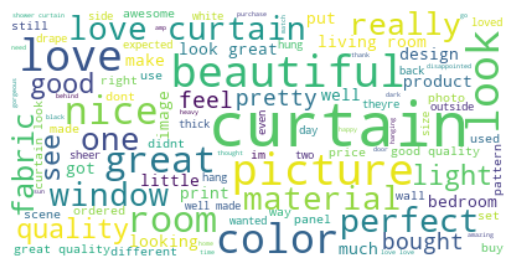

In [33]:
# Wordcloud görselleştirme

from wordcloud import WordCloud

text = " ".join(i for i in df.Review)
wordCloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text)
plt.imshow(wordCloud, interpolation="bilinear")
plt.axis("off")
plt.show()


### Duygu Analizi

In [40]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\İlayda\AppData\Roaming\nltk_data...


True

In [41]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia=SentimentIntensityAnalyzer()

In [42]:
df["polarity_score"] = df['Review'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [43]:
df.head()

,Star,HelpFul,Title,Review,polarity_score
0,5,0,looks great,happy,0.5719
1,5,0,Pattern did not align between the two panels.,good quality material however panel,0.4404
2,5,0,Imagery is stretched. Still fun.,product fun bedroom windowsbr imagery bit stre...,0.7184
3,5,0,Que se ven elegantes muy finas,lo que e que un poco ma,0.0000
4,5,0,Wow great purchase,great bang buck cant believe quality material ...,0.9042


In [44]:
df["sentiment_label"] = df["Review"].apply(lambda x: 'pos' if sia.polarity_scores(x)['compound'] > 0 else "neg")

In [45]:
df.head()

,Star,HelpFul,Title,Review,polarity_score,sentiment_label
0,5,0,looks great,happy,0.5719,pos
1,5,0,Pattern did not align between the two panels.,good quality material however panel,0.4404,pos
2,5,0,Imagery is stretched. Still fun.,product fun bedroom windowsbr imagery bit stre...,0.7184,pos
3,5,0,Que se ven elegantes muy finas,lo que e que un poco ma,0.0000,neg
4,5,0,Wow great purchase,great bang buck cant believe quality material ...,0.9042,pos


### Makine Öğrenmesine Hazırlık

In [49]:
# Veriyi train ve test olarak ayırma

y = df["sentiment_label"]
X = df["Review"]

In [50]:
from sklearn.model_selection import train_test_split

# Veriyi train ve test olarak ayır
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf_vectorizer = TfidfVectorizer()

In [54]:
# train verisini fit etme

tf_idf_vectorizer.fit(X_train)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [55]:
# Train ve test verilerini transform et
X_train_tfidf = tf_idf_vectorizer.transform(X_train)
X_test_tfidf = tf_idf_vectorizer.transform(X_test)

### Modelleme

In [56]:
# Lojistik Regresyon Modeli
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [58]:
y_pred = log_model.predict(X_test_tfidf)

In [60]:
# sonuçları değerlendirme

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         neg       0.91      0.40      0.55       179
         pos       0.90      0.99      0.94       944

    accuracy                           0.90      1123
   macro avg       0.90      0.69      0.75      1123
weighted avg       0.90      0.90      0.88      1123



In [61]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(log_model, X_train_tfidf, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Average CV score:", np.mean(cv_scores))

Cross-validation scores: [0.88641425 0.88530067 0.87639198 0.89297659 0.89520624]
Average CV score: 0.8872579471785438


In [62]:
# df'den rastgele 1 yorum seçimi
sample_review = df['Review'].sample(n=1, random_state=42).iloc[0]

print("Seçilen Örnek Yorum:")
print(sample_review)

Seçilen Örnek Yorum:
love curtain make feel like im looking ocean would order heartbeat


In [63]:
from sklearn.feature_extraction.text import CountVectorizer

# Örnek yorumu transform et
count_vectorizer = CountVectorizer(stop_words='english')
count_vectorizer.fit(X_train)  
sample_vector = count_vectorizer.transform([sample_review])

In [67]:
sample_vector = tf_idf_vectorizer.transform([sample_review])

In [68]:
# Kurulan model ile tahmin
sample_pred = log_model.predict(sample_vector)

print("Tahmin Sonucu:", sample_pred[0])

Tahmin Sonucu: pos


In [69]:
print("\n=== Örnek Yorum ve Tahmin ===")
print("Yorum: ", sample_review)
print("Tahmin Edilen Sınıf: ", sample_pred[0])


=== Örnek Yorum ve Tahmin ===
Yorum:  love curtain make feel like im looking ocean would order heartbeat
Tahmin Edilen Sınıf:  pos


In [70]:
# Random Forest Modeli

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train_tfidf, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
y_pred = rf_model.predict(X_test_tfidf)

In [72]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         neg       0.79      0.58      0.67       179
         pos       0.92      0.97      0.95       944

    accuracy                           0.91      1123
   macro avg       0.86      0.78      0.81      1123
weighted avg       0.90      0.91      0.90      1123



In [73]:
cv_scores = cross_val_score(rf_model, X_train_tfidf, y_train, cv=5)

print("Cross-validation scores:", cv_scores)
print("Average CV score:", np.mean(cv_scores))

Cross-validation scores: [0.9142539  0.91648107 0.92093541 0.90746934 0.90412486]
Average CV score: 0.9126529163035408
